# Energy Consumption Analysis — Nexus Elante Mall
**Pipeline:** Load → Clean → EDA → Correlation → Regression → Evaluate → Visualize

Drop additional yearly CSV/Excel files into the `DATA_DIR` folder; they will be picked up automatically.

---
## Step 1 — Import Libraries

In [1]:
# Step 1 — Import Libraries

import warnings
import re
from pathlib import Path

import numpy  as np
import pandas as pd

import matplotlib.pyplot  as plt
import matplotlib.ticker  as ticker
import seaborn            as sns

from sklearn.linear_model    import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_predict
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 30)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully.')


Libraries loaded successfully.


---
## Step 2 — Load All Data Files Dynamically

The loader scans `DATA_DIR` for every `.csv`, `.xlsx`, and `.xls` file.
It auto-detects the year embedded in each file and handles both the 2023-style
(single header row) and 2024-style (multi-level header) layouts.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — change this path if you run the notebook from a different location
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR = Path('.')
SUPPORTED_EXTS = {'.csv', '.xlsx', '.xls'}

MONTH_ORDER = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]


# ── Helper: read raw file ─────────────────────────────────────────────────────
def _read_raw(filepath: Path) -> pd.DataFrame:
    """Read a file into a raw DataFrame with no header parsing."""
    ext = filepath.suffix.lower()
    if ext == '.csv':
        return pd.read_csv(filepath, header=None, dtype=str)
    return pd.read_excel(filepath, header=None, dtype=str)


# ── Helper: extract year from raw data ───────────────────────────────────────
def _extract_year(raw: pd.DataFrame) -> int:
    """
    Scan every cell for a 4-digit year (2020-2030).
    Returns the first match found, or 0 if none.
    """
    for _, row in raw.iterrows():
        for val in row:
            m = re.search(r'\b(20[2-9]\d)\b', str(val))
            if m:
                return int(m.group(1))
    return 0


# ── Helper: find the row index where 'Months' lives ──────────────────────────
def _months_row_idx(raw: pd.DataFrame) -> int:
    """Return the 0-based row index of the header row that contains 'Months'."""
    for i, row in raw.iterrows():
        if row.astype(str).str.strip().eq('Months').any():
            return i
    raise ValueError("Could not find a row containing 'Months' in the file.")


# ── Helper: detect multi-level vs single-level header layout ─────────────────
def _is_multilevel(raw: pd.DataFrame, header_row: int) -> bool:
    """
    Return True when the row immediately above *header_row* contains genuine
    group labels (e.g. 'HVAC Tenants', 'Hotel', 'Office Tenants').

    2023-style: the row above 'Months' only has a year number -> False.
    2024-style: that row has 3+ category strings -> True.
    """
    if header_row < 1:
        return False
    above = raw.iloc[header_row - 1].fillna('').astype(str).str.strip()
    meaningful = [
        v for v in above
        if v
        and v.lower() not in ('nan', '', 'year')
        and not re.match(r'^\d{4}$', v)
    ]
    return len(meaningful) >= 3


# ── Helper: build column names for multi-level layout ────────────────────────
def _build_multilevel_columns(raw: pd.DataFrame, header_row: int) -> list:
    """
    Combine the group row (header_row - 1) and the label row (header_row)
    into clean, unique column names.

    e.g.  group='HVAC Tenants', label='EB'  ->  'HVAC Tenants_EB'
    """
    group_row = raw.iloc[header_row - 1].fillna('').astype(str).str.strip()
    label_row = raw.iloc[header_row    ].fillna('').astype(str).str.strip()

    last_group = ''
    cols = []
    for i, (g, l) in enumerate(zip(group_row, label_row)):
        if g and g.lower() not in ('nan', ''):
            last_group = g
        if l and l.lower() not in ('nan', ''):
            if last_group and last_group != l:
                cols.append(f"{last_group}_{l}")
            else:
                cols.append(l)
        else:
            cols.append(last_group if last_group else f'Col_{i}')
    return cols


# ── Core parser ───────────────────────────────────────────────────────────────
def parse_file(filepath: Path) -> pd.DataFrame:
    """
    Parse one data file into a clean DataFrame.

    Layout detection
    ----------------
    * Single-level header (e.g. 2023): the row above 'Months' contains only
      year info -> use that row directly as column names.
    * Multi-level header  (e.g. 2024): the row above 'Months' carries group
      labels ('Hotel', 'HVAC Tenants', ...) -> combine both rows into names.

    Post-processing
    ---------------
    * Drop Total/summary rows.
    * Add 'Year' and 'Month_Num' columns.
    """
    raw  = _read_raw(filepath)
    year = _extract_year(raw)
    hr   = _months_row_idx(raw)        # 0-based index of the Months header row

    if _is_multilevel(raw, hr):
        # 2024 style: compound column names from two header rows
        col_names = _build_multilevel_columns(raw, hr)
    else:
        # 2023 style: single header row is sufficient
        col_names = raw.iloc[hr].astype(str).str.strip().tolist()

    df = raw.iloc[hr + 1:].copy()
    df.columns = col_names

    # Tidy column names: strip whitespace, collapse multiple spaces
    df.columns = [re.sub(r'\s+', ' ', c).strip() for c in df.columns]

    # Keep only valid monthly rows (drop totals, blank rows, header repeats)
    df = df[
        df['Months'].notna() &
        (~df['Months'].astype(str).str.strip().str.match(
            r'^(Total|Months|nan|\s*)$', case=False
        ))
    ].copy()

    df['Months']    = df['Months'].astype(str).str.strip()
    df['Year']      = year
    month_map       = {m: i + 1 for i, m in enumerate(MONTH_ORDER)}
    df['Month_Num'] = df['Months'].map(month_map)

    df = df.reset_index(drop=True)
    print(f"  Loaded: {filepath.name!s:60s} -> {len(df):>2} rows, "
          f"{len(df.columns)} cols  (Year={year})")
    return df


# ── Master loader ─────────────────────────────────────────────────────────────
def load_all_files(folder: Path) -> dict:
    """
    Scan *folder* for all supported data files and return a dict:
        { year (int) : DataFrame }

    Simply drop a new year's file into the folder — it will be picked up
    automatically on the next run.
    """
    files = sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
    )

    if not files:
        raise FileNotFoundError(f"No CSV / Excel files found in: {folder.resolve()}")

    print(f"Found {len(files)} file(s) in '{folder.resolve()}':\n")
    datasets = {}
    for fp in files:
        df = parse_file(fp)
        datasets[df['Year'].iloc[0]] = df

    print(f"\nDatasets loaded for years: {sorted(datasets.keys())}")
    return datasets


# ── Run ───────────────────────────────────────────────────────────────────────
datasets = load_all_files(DATA_DIR)


FileNotFoundError: No CSV / Excel files found in: C:\Users\Asus\Desktop\ML\major

---
## Step 3 — Data Cleaning & Preprocessing

In [3]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    1. Convert all non-identifier columns to numeric.
    2. Drop columns that are entirely NaN or have zero variance
       (id columns — Months, Year, Month_Num — are always preserved).
    3. Fill remaining NaNs with column medians (robust to outliers).
    4. Remove rows where the target 'Consumption' is missing.
    """
    df = df.copy()
    id_cols = {'Months', 'Year', 'Month_Num'}

    # Convert every non-id column to numeric
    for col in df.columns:
        if col not in id_cols:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', ''), errors='coerce'
            )

    # Drop columns that are entirely NaN
    df.dropna(axis=1, how='all', inplace=True)

    # Drop zero-variance columns — but never touch id columns
    num_cols = df.select_dtypes(include='number').columns
    zero_var = [c for c in num_cols if c not in id_cols and df[c].std() == 0]
    if zero_var:
        print(f"  Dropping zero-variance columns: {zero_var}")
    df.drop(columns=zero_var, inplace=True)

    # Remove rows without a Consumption value
    if 'Consumption' in df.columns:
        before = len(df)
        df.dropna(subset=['Consumption'], inplace=True)
        dropped = before - len(df)
        if dropped:
            print(f"  Dropped {dropped} row(s) with missing Consumption.")

    # Median-impute remaining numeric NaNs (excluding id columns)
    num_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in id_cols]
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    return df.reset_index(drop=True)


# Clean every loaded dataset
cleaned = {}
for year, df in datasets.items():
    print(f"\nCleaning {year} dataset:")
    cleaned[year] = clean_dataframe(df)


# Build a combined DataFrame using columns common to ALL years
common_cols = set.intersection(*[set(df.columns) for df in cleaned.values()])

df_combined = pd.concat(
    [df[sorted(common_cols)] for df in cleaned.values()],
    ignore_index=True
).sort_values(['Year', 'Month_Num']).reset_index(drop=True)

print(f"\nCommon columns across all years: {sorted(common_cols)}")
print(f"Combined dataset shape         : {df_combined.shape}")
print("\nSample of combined data:")
df_combined.head(6)



Cleaning 2023 dataset:

Cleaning 2024 dataset:

Common columns across all years: ['Consumption', 'Month_Num', 'Months', 'Year']
Combined dataset shape         : (24, 4)

Sample of combined data:


,Consumption,Month_Num,Months,Year
0,2226000,1,January,2023
1,2243000,2,February,2023
2,2714000,3,March,2023
3,2752000,4,April,2023
4,3661000,5,May,2023
5,3617000,6,June,2023


In [4]:
# ── Quick schema check per year ───────────────────────────────────────────────
for year, df in cleaned.items():
    print(f"\n{'─'*60}")
    print(f" {year} — shape: {df.shape}")
    print(f"{'─'*60}")
    print(df.describe(include='number').T[['count', 'mean', 'std', 'min', 'max']])


────────────────────────────────────────────────────────────
 2023 — shape: (12, 19)
────────────────────────────────────────────────────────────
             count      mean     std       min       max
Consumption     12 3,107,667 675,078 2,226,000 4,029,000
Mall Solar      12    23,545   5,675    11,967    30,751
Mall            12 2,394,275 547,483 1,552,201 3,117,386
Mall DG         12     7,446   8,806         0    22,957
Tenant          12 1,317,058 168,972   934,687 1,530,346
Tenant DG       12     3,582   4,249         0    10,760
HVAC            12   806,118 377,997   238,265 1,273,896
HVAC DG         12     3,077   3,630         0     9,543
CA Lighting     12   294,644  57,624   213,375   400,195
CA DG           12       152     376         0     1,321
OB              12   203,771  35,365   135,750   260,000
OB DG           12       196     256         0       653
OB Solar        12     7,578   4,336         0    14,737
Hotel Solar     12    13,476  16,020     3,635    49,39

---
## Step 4 — Exploratory Data Analysis (EDA)

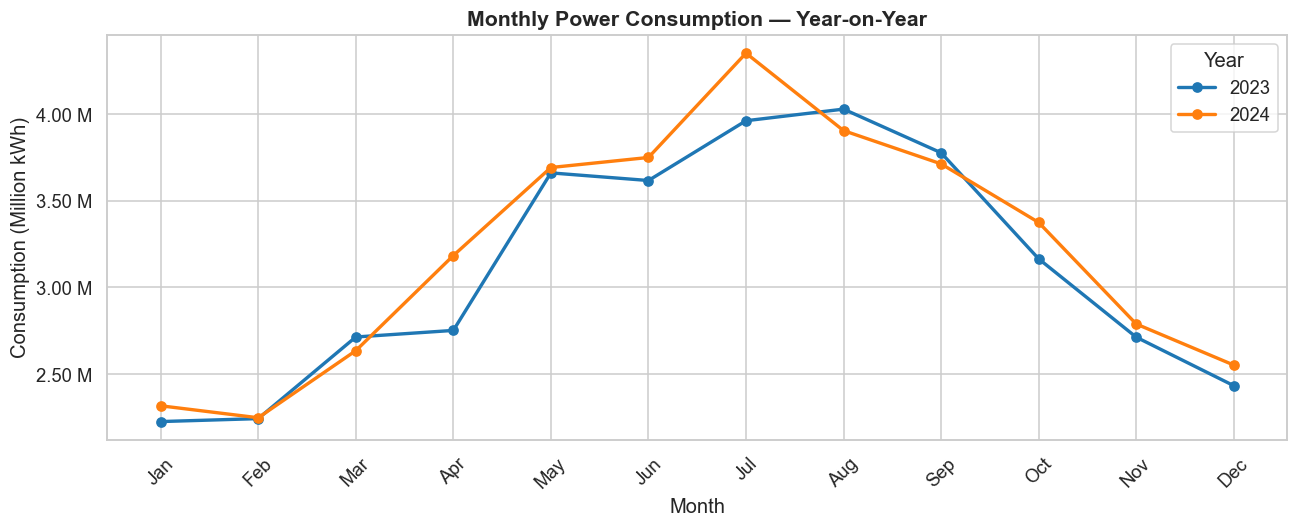

In [5]:
# ── 4a  Monthly consumption trend — all years overlaid ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

palette = sns.color_palette('tab10', n_colors=len(cleaned))
for (year, df), color in zip(sorted(cleaned.items()), palette):
    df_sorted = df.sort_values('Month_Num')
    ax.plot(
        df_sorted['Month_Num'], df_sorted['Consumption'] / 1e6,
        marker='o', linewidth=2.2, label=str(year), color=color
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f} M"))
ax.set_title('Monthly Power Consumption — Year-on-Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Consumption (Million kWh)')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

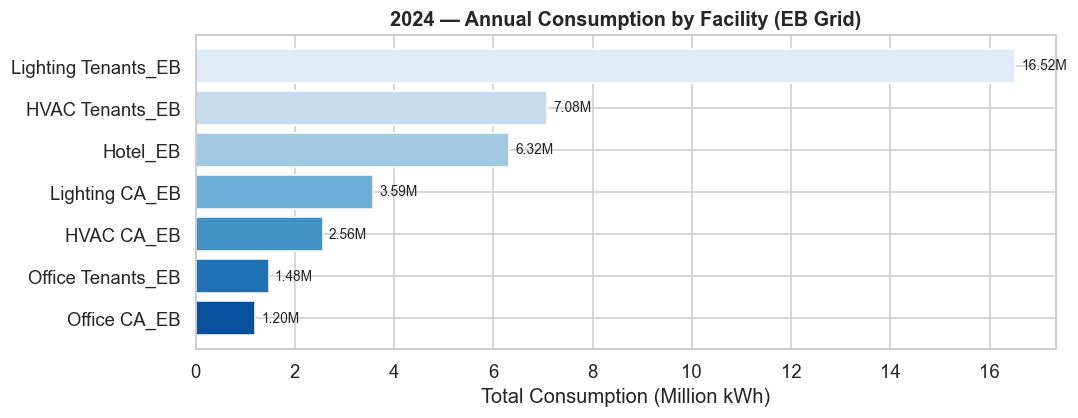

In [6]:
# ── 4b  Sub-facility breakdown (2023) ────────────────────────────────────────
# Select the latest-year dataset with the richest sub-meter columns
primary_year = max(cleaned.keys())
df_p = cleaned[primary_year]

# Identify EB (grid) sub-meter columns — exclude DG/Solar/meta columns
exclude_patterns = r'(DG|Solar|Consumption|Bill|Year|Month|Col_|YoY|24 to 23)'
facility_cols = [
    c for c in df_p.select_dtypes(include='number').columns
    if c != 'Consumption' and not re.search(exclude_patterns, c, re.IGNORECASE)
]

if facility_cols:
    totals = df_p[facility_cols].sum().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(totals) * 0.45)))
    bars = ax.barh(totals.index, totals.values / 1e6,
                   color=sns.color_palette('Blues_r', len(totals)))
    ax.bar_label(bars, fmt=lambda x: f"{x:.2f}M", padding=4, fontsize=9)
    ax.set_title(f'{primary_year} — Annual Consumption by Facility (EB Grid)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Total Consumption (Million kWh)')
    plt.tight_layout()
    plt.show()
else:
    print("No sub-facility columns identified for the primary year.")

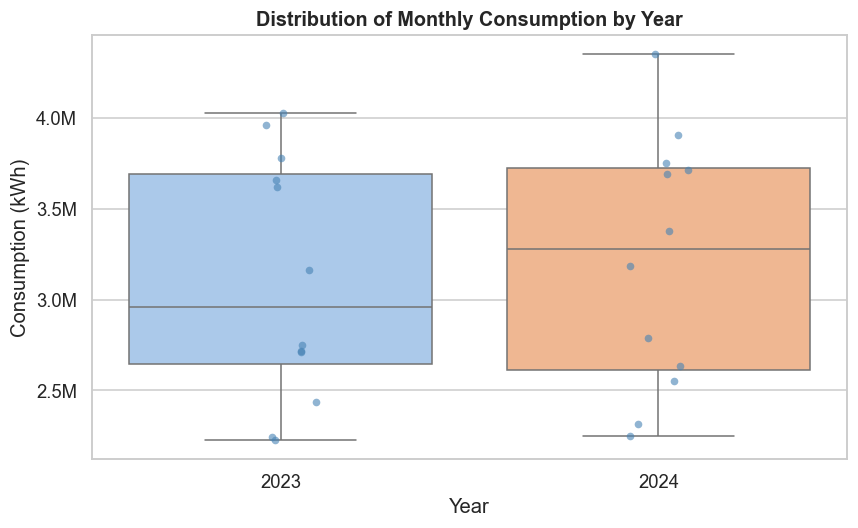

In [7]:
# ── 4c  Distribution of monthly consumption per year (box plot) ──────────────
df_box = df_combined[['Year', 'Consumption']].copy()
df_box['Year'] = df_box['Year'].astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_box, x='Year', y='Consumption', palette='pastel', ax=ax)
sns.stripplot(data=df_box, x='Year', y='Consumption',
              color='steelblue', alpha=0.6, jitter=True, ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title('Distribution of Monthly Consumption by Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Consumption (kWh)')
plt.tight_layout()
plt.show()

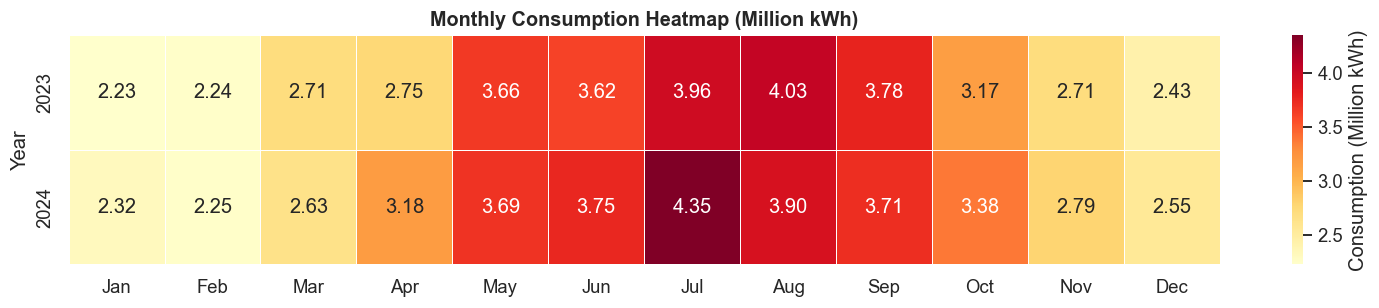

In [8]:
# ── 4d  Monthly heatmap (combined years) ─────────────────────────────────────
pivot = df_combined.pivot_table(
    index='Year', columns='Month_Num', values='Consumption', aggfunc='sum'
)
pivot.columns = [MONTH_ORDER[i - 1][:3] for i in pivot.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.9)))
sns.heatmap(
    pivot / 1e6, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Consumption (Million kWh)'}
)
ax.set_title('Monthly Consumption Heatmap (Million kWh)', fontsize=13, fontweight='bold')
ax.set_ylabel('Year')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

---
## Step 5 — Correlation Analysis

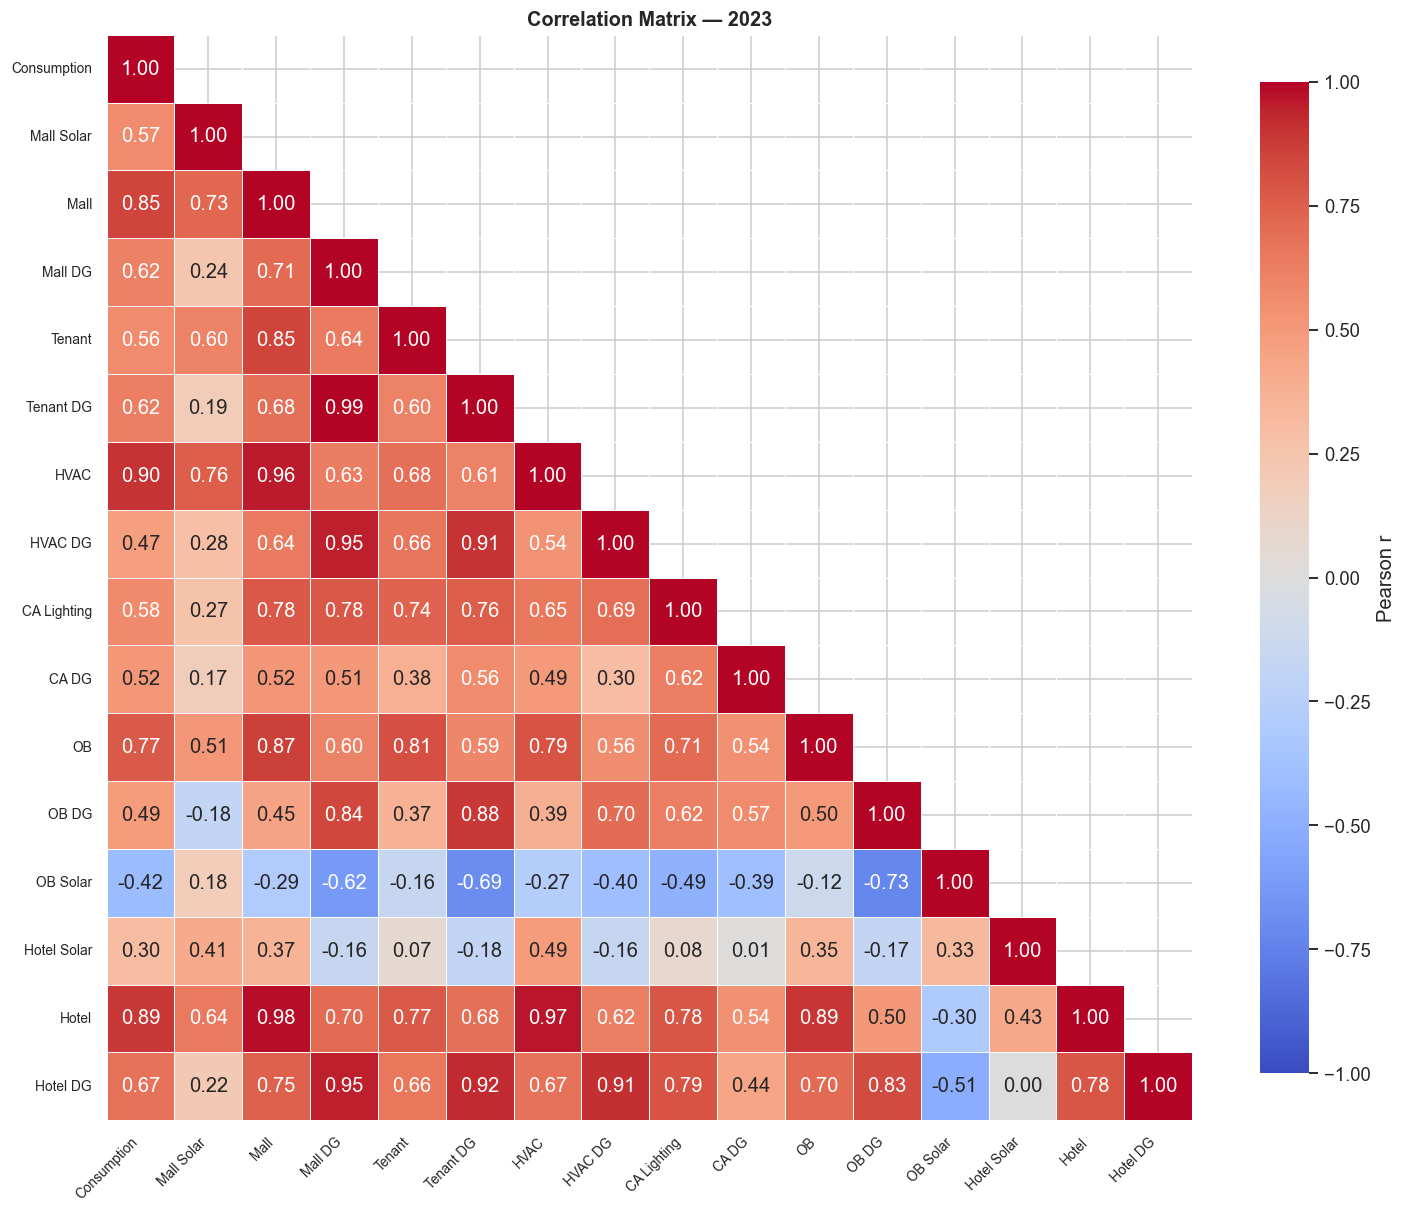


Top correlations with Consumption (2023):
  +0.901  HVAC
  +0.889  Hotel
  +0.851  Mall
  +0.768  OB
  +0.673  Hotel DG
  +0.621  Tenant DG
  +0.617  Mall DG
  +0.575  CA Lighting
  +0.568  Mall Solar
  +0.565  Tenant


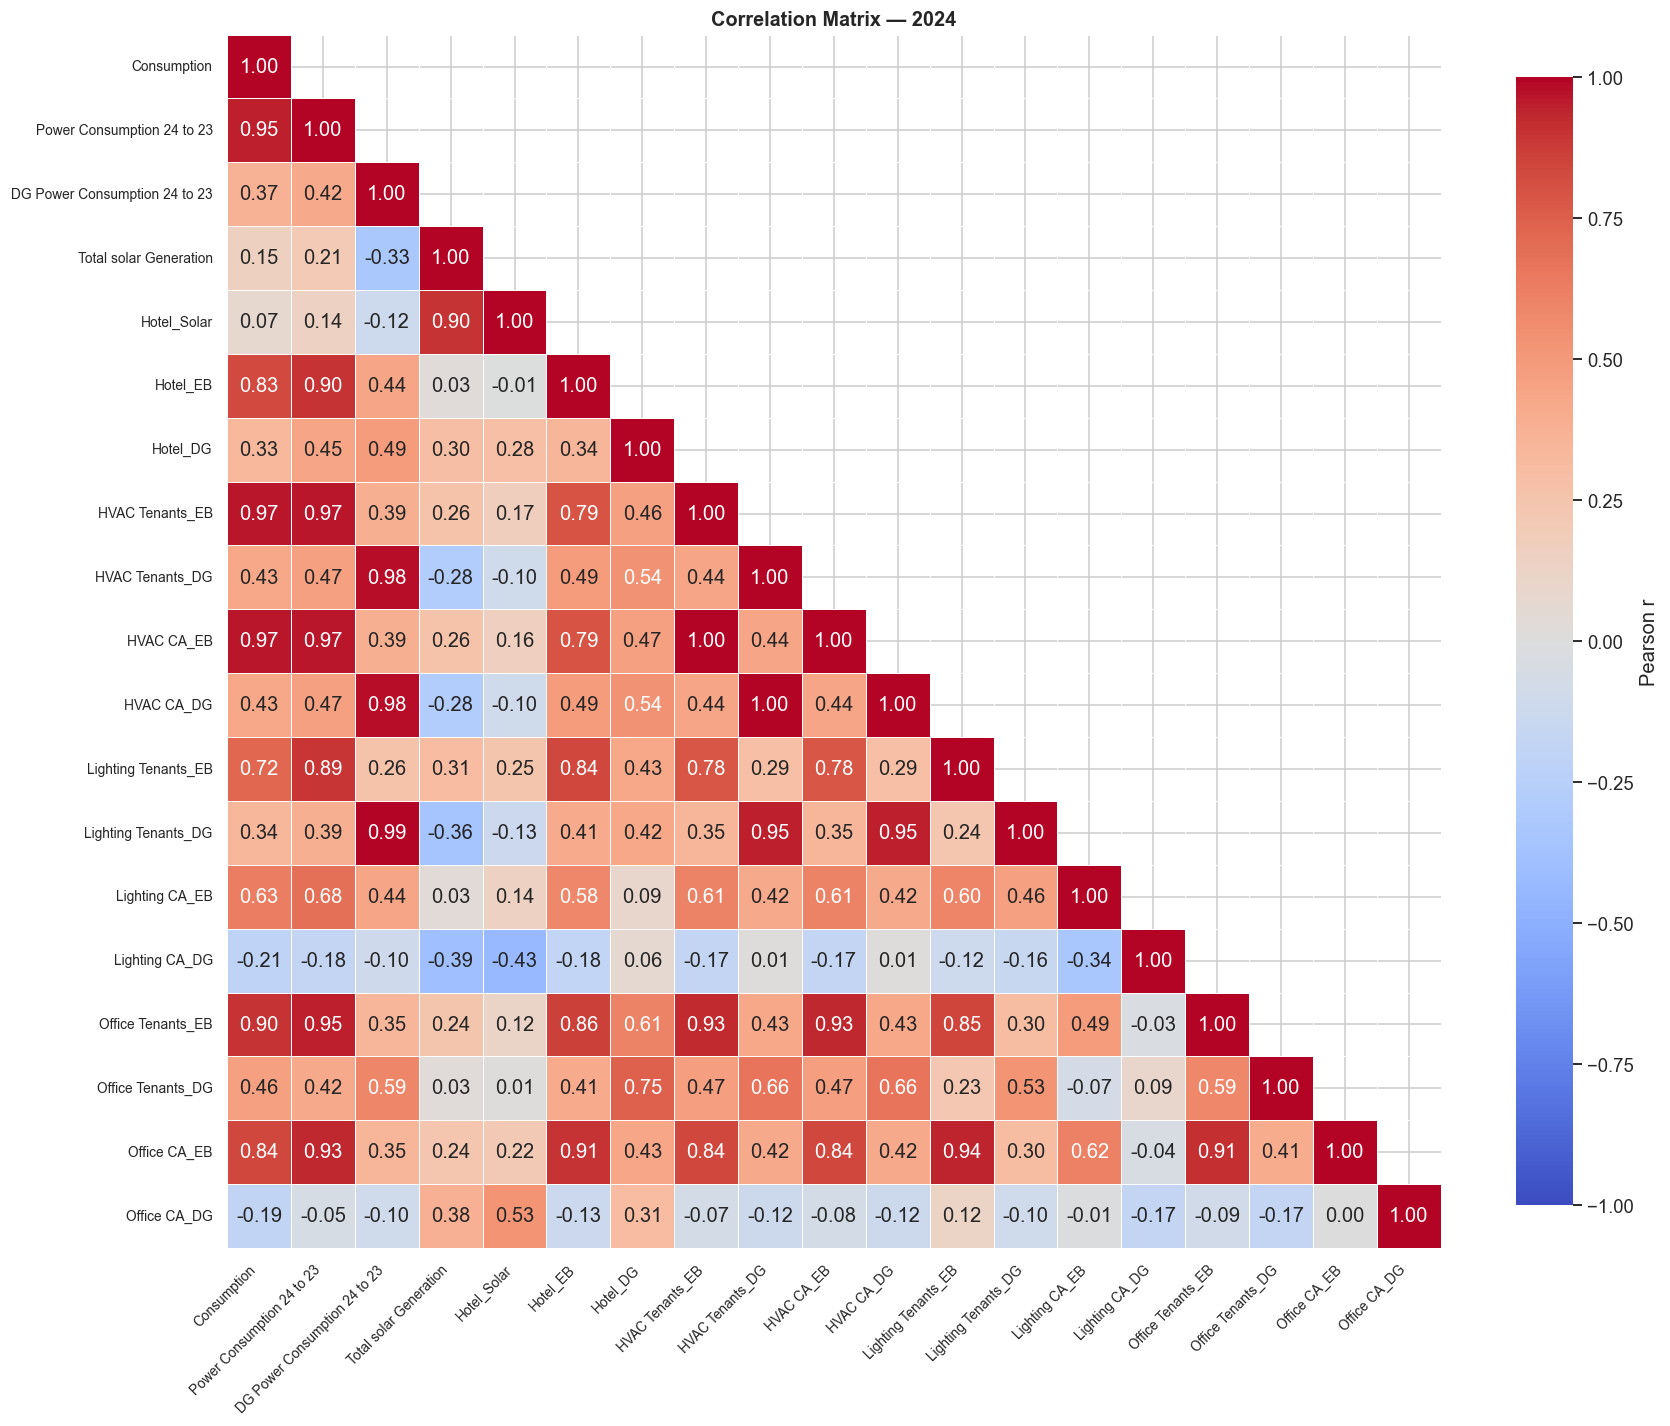


Top correlations with Consumption (2024):
  +0.966  HVAC CA_EB
  +0.965  HVAC Tenants_EB
  +0.946  Power Consumption 24 to 23
  +0.901  Office Tenants_EB
  +0.838  Office CA_EB
  +0.830  Hotel_EB
  +0.723  Lighting Tenants_EB
  +0.627  Lighting CA_EB
  +0.465  Office Tenants_DG
  +0.427  HVAC Tenants_DG


In [9]:
def compute_correlation(df: pd.DataFrame, title: str = '') -> pd.DataFrame:
    """
    Compute and visualise a Pearson correlation matrix for all
    numeric columns in *df* (excluding metadata columns).
    Returns the correlation DataFrame.
    """
    meta = {'Month_Num', 'Year'}
    num_df = df.select_dtypes(include='number').drop(
        columns=[c for c in meta if c in df.columns]
    )

    corr = num_df.corr(method='pearson')

    # ── Plot ─────────────────────────────────────────────────────────────
    n = len(corr)
    fig, ax = plt.subplots(figsize=(max(8, n * 0.85), max(6, n * 0.75)))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle

    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.4,
        cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
        ax=ax
    )
    ax.set_title(f'Correlation Matrix — {title}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Top correlations with Consumption ────────────────────────────────
    if 'Consumption' in corr.columns:
        top = (
            corr['Consumption']
            .drop('Consumption')
            .abs()
            .sort_values(ascending=False)
            .head(10)
        )
        print(f"\nTop correlations with Consumption ({title}):")
        for feat, val in top.items():
            direction = '+' if corr.loc[feat, 'Consumption'] >= 0 else '-'
            print(f"  {direction}{val:.3f}  {feat}")

    return corr


# ── Run correlation for each year ─────────────────────────────────────────────
correlations = {}
for year, df in sorted(cleaned.items()):
    correlations[year] = compute_correlation(df, title=str(year))

---
## Step 6 — Feature Selection & Train / Test Split

With only 12 monthly observations per year, using all 15+ sub-meter features
causes severe overfitting. We address this by:

1. **Correlation-based feature selection** — keep only the top-N features
   most correlated with `Consumption` (rule of thumb: samples / 3).
2. **Leave-One-Out Cross-Validation (LOOCV)** — the proper evaluation
   strategy for very small datasets.


In [10]:
def select_features(df: pd.DataFrame, target: str = 'Consumption',
                    max_features: int = None) -> list:
    """
    Return the top-N numeric features most correlated with *target*.

    Parameters
    ----------
    max_features : int or None
        If None, defaults to len(df) // 3 (rule of thumb to avoid
        overfitting with small samples).
    """
    exclude = {target, 'Year', 'Month_Num', 'Bill Copy'}
    leak_pattern = r'(24 to 23|YoY|Bill)'
    candidates = [
        c for c in df.select_dtypes(include='number').columns
        if c not in exclude and not re.search(leak_pattern, c, re.IGNORECASE)
    ]

    if max_features is None:
        max_features = max(2, len(df) // 3)   # at least 2 features

    # Rank by absolute correlation with the target
    corrs = df[candidates].corrwith(df[target]).abs().sort_values(ascending=False)
    selected = corrs.head(max_features).index.tolist()
    return selected


# Choose the year with the most sub-meter features for modelling
model_year = max(cleaned.keys(), key=lambda y: len(
    [c for c in cleaned[y].select_dtypes(include='number').columns
     if c not in {'Consumption','Year','Month_Num','Bill Copy'}]
))
df_model = cleaned[model_year]
TARGET   = 'Consumption'
FEATURES = select_features(df_model, TARGET)

print(f"Model dataset  : {model_year}  ({len(df_model)} samples)")
print(f"Target         : {TARGET}")
print(f"Max features   : {len(df_model) // 3}  (= {len(df_model)} samples / 3)")
print(f"\nSelected features ({len(FEATURES)}):")
corrs = df_model[FEATURES].corrwith(df_model[TARGET])
for f in FEATURES:
    print(f"  {f:30s}  corr = {corrs[f]:+.3f}")

X = df_model[FEATURES].values
y = df_model[TARGET].values

# Also prepare a traditional 75/25 split for comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"\nTrain samples  : {len(X_train)}")
print(f"Test  samples  : {len(X_test)}")


Model dataset  : 2024  (12 samples)
Target         : Consumption
Max features   : 4  (= 12 samples / 3)

Selected features (4):
  HVAC CA_EB                      corr = +0.966
  HVAC Tenants_EB                 corr = +0.965
  Office Tenants_EB               corr = +0.901
  Office CA_EB                    corr = +0.838

Train samples  : 9
Test  samples  : 3


---
## Step 7 — Build Regression Models

Two models are trained for comparison:

| Model | Why |
|---|---|
| `LinearRegression` | Baseline — no regularization |
| `RidgeCV` | Adds L2 penalty; alpha auto-tuned via built-in LOOCV |

Both are wrapped in a `StandardScaler -> Regressor` pipeline.


In [11]:
# Step 7 — Build Regression Models

# --- Model A: Plain Linear Regression (baseline) ---
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
pipe_lr.fit(X_train, y_train)

# --- Model B: RidgeCV (L2 regularisation, alpha auto-tuned via LOOCV) ---
alphas = np.logspace(-2, 6, 50)
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RidgeCV(alphas=alphas, cv=LeaveOneOut()))
])
pipe_ridge.fit(X, y)    # fit on ALL data — LOOCV is built into RidgeCV

best_alpha = pipe_ridge.named_steps['regressor'].alpha_
print(f"RidgeCV best alpha : {best_alpha:,.2f}\n")

# --- LOOCV predictions (unbiased estimate for small data) ---
# Each sample is predicted by a model trained on the other 11
y_pred_loocv = cross_val_predict(
    Pipeline([('scaler', StandardScaler()), ('regressor', RidgeCV(alphas=alphas))]),
    X, y, cv=LeaveOneOut()
)

# Standardised coefficients from the full-data Ridge model
coefs = pd.Series(
    pipe_ridge.named_steps['regressor'].coef_,
    index=FEATURES
).sort_values(key=abs, ascending=False)

print("Standardised coefficients (Ridge, |coef| sorted):")
print(coefs.to_string())

# Keep references for Steps 8 & 9
model = pipe_ridge


RidgeCV best alpha : 0.01

Standardised coefficients (Ridge, |coef| sorted):
HVAC CA_EB          527,694
HVAC Tenants_EB      97,064
Office CA_EB         80,306
Office Tenants_EB   -57,741


---
## Step 8 — Model Evaluation

Two evaluation strategies are compared:

| Strategy | Description |
|---|---|
| **LOOCV (Ridge)** | Leave-One-Out Cross-Validation — each of the 12 months is predicted by a model trained on the other 11. Unbiased for small data. |
| **Hold-out (Linear Reg)** | Traditional 75/25 split — shown for reference only; unreliable with 3 test samples. |


In [12]:
# Step 8 — Evaluate both models

def calc_metrics(y_true, y_pred, label):
    """Compute R2, MAE, RMSE and return as a dict."""
    return {
        'label': label,
        'R2'   : r2_score(y_true, y_pred),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
    }

# --- Primary: LOOCV Ridge ---
m_loocv = calc_metrics(y, y_pred_loocv, 'RidgeCV  (LOOCV)')

# --- Baseline: Hold-out Linear Regression ---
y_pred_lr = pipe_lr.predict(X_test)
m_holdout = calc_metrics(y_test, y_pred_lr, 'LinearReg (hold-out)')

# --- Print report ---
print("=" * 55)
print("  MODEL EVALUATION REPORT")
print("=" * 55)
for m in [m_loocv, m_holdout]:
    print(f"\n  {m['label']}")
    print(f"    R2   : {m['R2']:.4f}")
    print(f"    MAE  : {m['MAE']:>12,.0f} kWh")
    print(f"    RMSE : {m['RMSE']:>12,.0f} kWh")
print("\n" + "=" * 55)

r2 = m_loocv['R2']
if r2 >= 0.90:
    note = "Excellent fit -- model explains >90% of variance."
elif r2 >= 0.70:
    note = "Good fit -- sub-meter readings are strong predictors."
elif r2 >= 0.50:
    note = "Moderate fit -- consider additional features or non-linear models."
else:
    note = "Weak fit -- linear regression may not capture the relationship well."
print(f"  LOOCV verdict: {note}")

# Keep the LOOCV metrics as the primary metrics dict
metrics = m_loocv
y_pred  = y_pred_loocv


  MODEL EVALUATION REPORT

  RidgeCV  (LOOCV)
    R2   : 0.8605
    MAE  :      199,171 kWh
    RMSE :      247,149 kWh

  LinearReg (hold-out)
    R2   : 0.8177
    MAE  :      161,576 kWh
    RMSE :      184,773 kWh

  LOOCV verdict: Good fit -- sub-meter readings are strong predictors.


---
## Step 9 — Result Visualisations

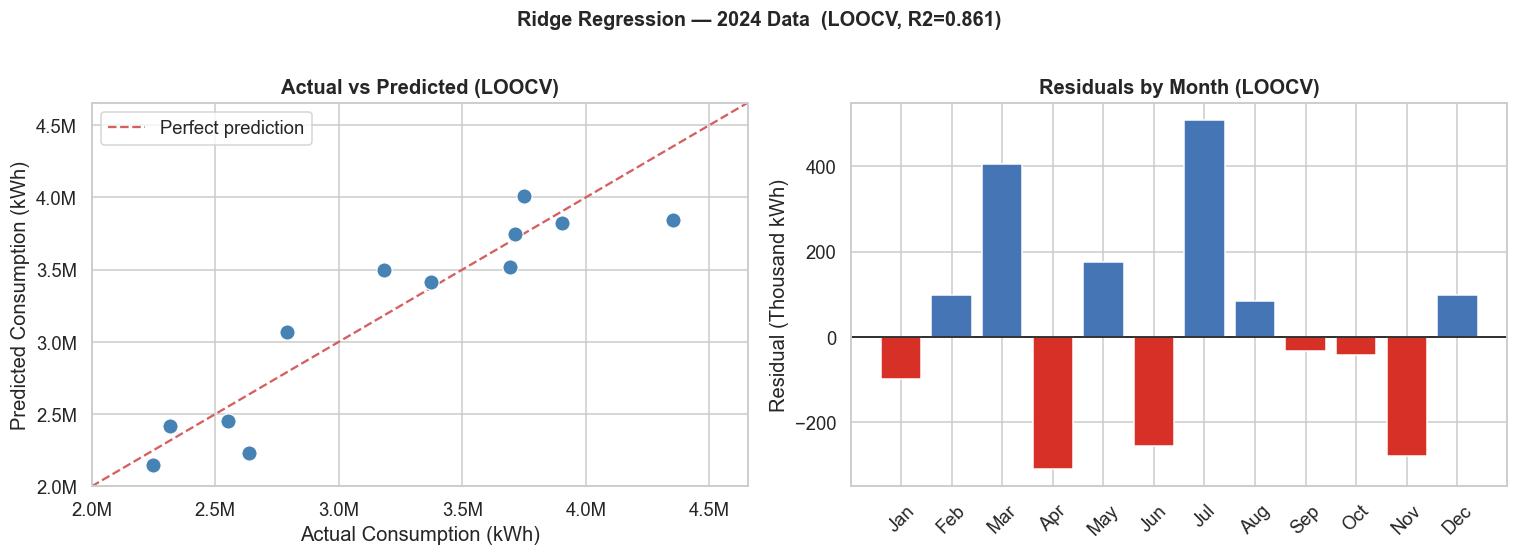

In [13]:
# 9a — Actual vs Predicted scatter + Residuals (LOOCV, all 12 months)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y, y_pred, color='steelblue', edgecolors='white',
           s=100, linewidths=0.8, zorder=3)
lims = [min(y.min(), y_pred.min()) * 0.93,
        max(y.max(), y_pred.max()) * 1.07]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title('Actual vs Predicted (LOOCV)', fontweight='bold')
ax.set_xlabel('Actual Consumption (kWh)')
ax.set_ylabel('Predicted Consumption (kWh)')
ax.legend()

# Residuals bar chart
ax = axes[1]
months_sorted = df_model.sort_values('Month_Num')['Months'].values
idx_sorted = df_model['Month_Num'].argsort().values
residuals = (y - y_pred)[idx_sorted]
colors = ['#d73027' if r < 0 else '#4575b4' for r in residuals]
ax.bar(range(len(residuals)), residuals / 1e3, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(months_sorted)))
ax.set_xticklabels([m[:3] for m in months_sorted], rotation=45)
ax.set_title('Residuals by Month (LOOCV)', fontweight='bold')
ax.set_ylabel('Residual (Thousand kWh)')

plt.suptitle(f'Ridge Regression — {model_year} Data  (LOOCV, R2={metrics["R2"]:.3f})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


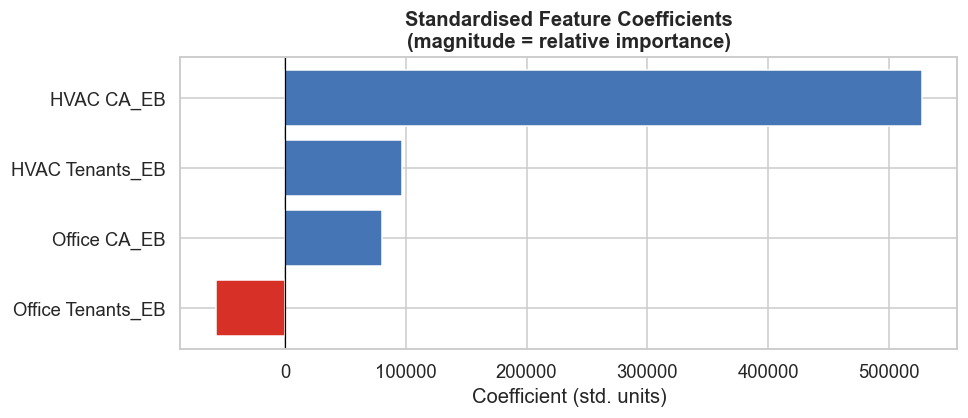

In [14]:
# ── 9b  Feature coefficients (standardised) ──────────────────────────────────
coef_plot = coefs.sort_values()          # ascending for horizontal bar readability

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_plot) * 0.5)))
colors = ['#d73027' if v < 0 else '#4575b4' for v in coef_plot]
ax.barh(coef_plot.index, coef_plot.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Standardised Feature Coefficients\n(magnitude = relative importance)',
             fontweight='bold')
ax.set_xlabel('Coefficient (std. units)')
plt.tight_layout()
plt.show()

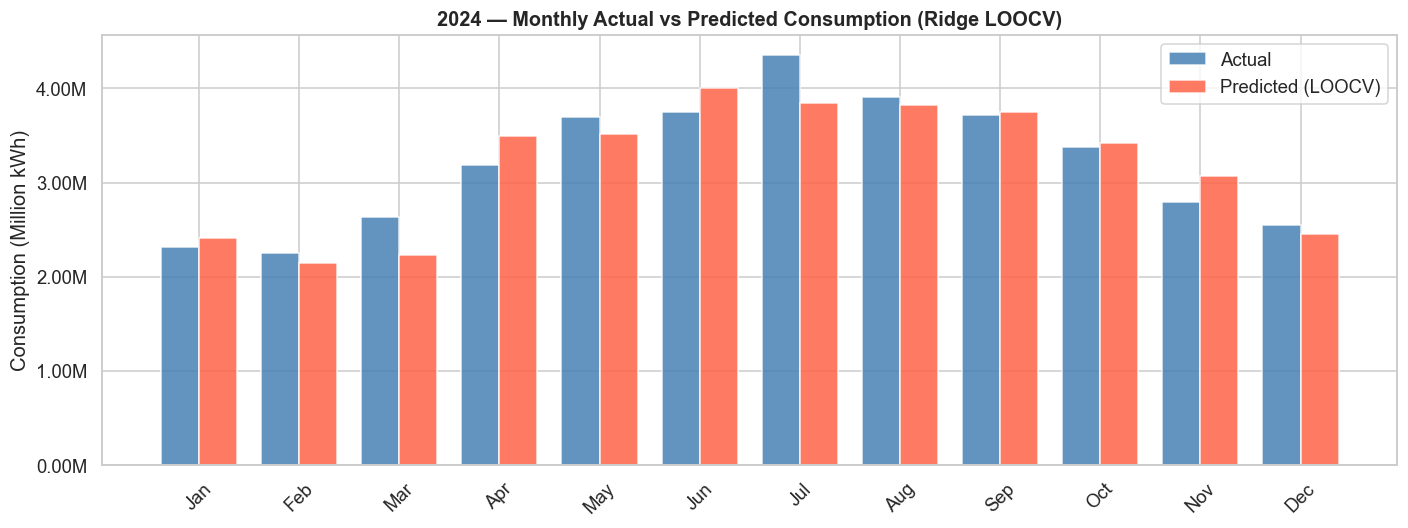

In [15]:
# 9c — Full-year Actual vs Predicted bar chart (LOOCV)

idx_sorted = df_model['Month_Num'].argsort().values
months_sorted = df_model.sort_values('Month_Num')['Months'].tolist()
y_actual_sorted = y[idx_sorted]
y_pred_sorted   = y_pred[idx_sorted]

fig, ax = plt.subplots(figsize=(13, 5))
x_pos = np.arange(len(months_sorted))
w = 0.38
ax.bar(x_pos - w/2, y_actual_sorted / 1e6, width=w, label='Actual',
       color='steelblue', alpha=0.85)
ax.bar(x_pos + w/2, y_pred_sorted   / 1e6, width=w, label='Predicted (LOOCV)',
       color='tomato',    alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels([m[:3] for m in months_sorted], rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}M"))
ax.set_title(f'{model_year} — Monthly Actual vs Predicted Consumption (Ridge LOOCV)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Consumption (Million kWh)')
ax.legend()
plt.tight_layout()
plt.show()


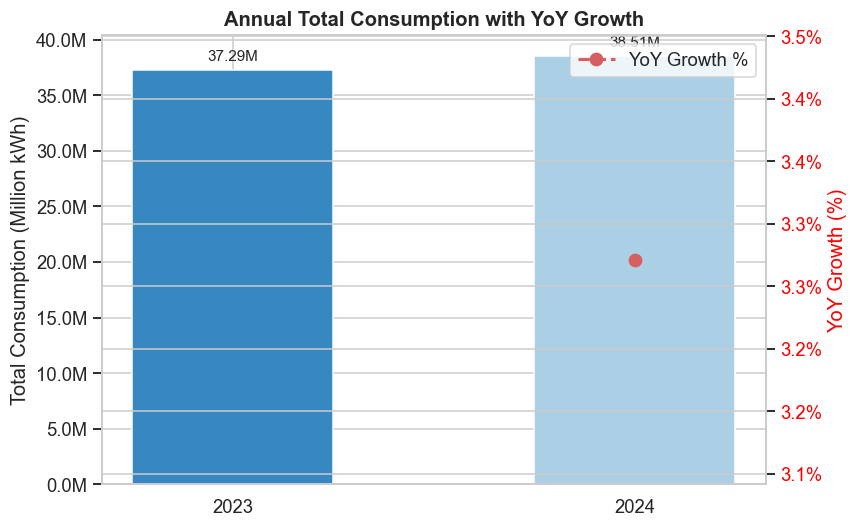

 Year  Consumption  Growth %
 2023     37292000       NaN
 2024     38512000         3


In [16]:
# ── 9d  Year-on-Year total consumption comparison ────────────────────────────
annual = (
    df_combined
    .groupby('Year')['Consumption']
    .sum()
    .reset_index()
    .sort_values('Year')
)
annual['Growth %'] = annual['Consumption'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(
    annual['Year'].astype(str), annual['Consumption'] / 1e6,
    color=sns.color_palette('Blues_r', len(annual)), width=0.5, edgecolor='white'
)
ax1.bar_label(bars, fmt=lambda x: f"{x:.2f}M", padding=4, fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax1.set_ylabel('Total Consumption (Million kWh)')
ax1.set_title('Annual Total Consumption with YoY Growth', fontweight='bold')

# Overlay growth rate on a twin axis
ax2 = ax1.twinx()
ax2.plot(
    annual['Year'].astype(str), annual['Growth %'],
    'ro--', linewidth=2, markersize=8, label='YoY Growth %'
)
ax2.set_ylabel('YoY Growth (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(annual.to_string(index=False))

In [17]:
# Final summary
print("\n" + "=" * 55)
print("  ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Years analysed    : {sorted(cleaned.keys())}")
print(f"  Regression year   : {model_year}")
print(f"  Target variable   : {TARGET}")
print(f"  Features used     : {len(FEATURES)}  {FEATURES}")
print(f"  Evaluation        : Leave-One-Out Cross-Validation")
print(f"  R2   (LOOCV)      : {metrics['R2']:.4f}")
print(f"  MAE  (LOOCV)      : {metrics['MAE']:,.0f} kWh")
print(f"  RMSE (LOOCV)      : {metrics['RMSE']:,.0f} kWh")
print("=" * 55)



  ANALYSIS COMPLETE
  Years analysed    : [np.int64(2023), np.int64(2024)]
  Regression year   : 2024
  Target variable   : Consumption
  Features used     : 4  ['HVAC CA_EB', 'HVAC Tenants_EB', 'Office Tenants_EB', 'Office CA_EB']
  Evaluation        : Leave-One-Out Cross-Validation
  R2   (LOOCV)      : 0.8605
  MAE  (LOOCV)      : 199,171 kWh
  RMSE (LOOCV)      : 247,149 kWh
